In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# **GPU Verification****

In [1]:
import torch

print("GPU Available:", torch.cuda.is_available())

print(
    "GPU Name:",
    torch.cuda.get_device_name(0)
)

GPU Available: True
GPU Name: Tesla T4


# Import Required Libraries****

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision import models

from tqdm import tqdm

# Device Configuration

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using Device:", device)

Using Device: cuda


# Dataset Path Verification

In [6]:
dataset_root = "/kaggle/input"

for root, dirs, files in os.walk(dataset_root):

    if len(files) > 0:

        print(root)

        print(files[:5])

        

/kaggle/input/datasets/teykaicong/iamondb-handwriting-dataset
['xml.tgz', 'words.tgz']


# Dataset Extraction

In [7]:
import tarfile


dataset_path = "/kaggle/input/datasets/teykaicong/iamondb-handwriting-dataset"


# Extract words
with tarfile.open(
    f"{dataset_path}/words.tgz"
) as tar:

    tar.extractall(
        path="/kaggle/working/"
    )


# Extract xml
with tarfile.open(
    f"{dataset_path}/xml.tgz"
) as tar:

    tar.extractall(
        path="/kaggle/working/"
    )


print("DATASET EXTRACTION COMPLETED")

/tmp/ipykernel_58/3163648805.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(
/tmp/ipykernel_58/3163648805.py:22: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(


DATASET EXTRACTION COMPLETED


# Dataset Verification

In [8]:
png_files = glob.glob(
    "/kaggle/working/**/*.png",
    recursive=True
)

xml_files = glob.glob(
    "/kaggle/working/**/*.xml",
    recursive=True
)

print("Total PNG Files:", len(png_files))

print("Total XML Files:", len(xml_files))


Total PNG Files: 115320
Total XML Files: 1539


# Writer Label Parsing

In [9]:
import xml.etree.ElementTree as ET


data = []


xml_paths = glob.glob(
    "/kaggle/working/**/*.xml",
    recursive=True
)


for xml_path in tqdm(xml_paths):

    try:

        tree = ET.parse(xml_path)

        root = tree.getroot()


        writer_id = root.attrib.get(
            "writer-id",
            "unknown"
        )


        for word in root.iter("word"):

            word_id = word.attrib.get("id")


            if word_id:

                folder1 = word_id[:3]

                folder2 = "-".join(
                    word_id.split("-")[:2]
                )


                image_path = (
                    f"/kaggle/working/"
                    f"{folder1}/"
                    f"{folder2}/"
                    f"{word_id}.png"
                )


                if os.path.exists(image_path):

                    data.append(
                        [
                            image_path,
                            writer_id
                        ]
                    )

    except Exception as e:

        print(e)


df = pd.DataFrame(
    data,
    columns=[
        "image_path",
        "writer_id"
    ]
)


print(df.head())

print("\nTotal Samples:", len(df))

print(
    "Unique Writers:",
    df["writer_id"].nunique()
)

100%|██████████| 1539/1539 [00:02<00:00, 636.91it/s]


                                      image_path writer_id
0  /kaggle/working/g07/g07-084/g07-084-00-00.png       355
1  /kaggle/working/g07/g07-084/g07-084-00-01.png       355
2  /kaggle/working/g07/g07-084/g07-084-00-02.png       355
3  /kaggle/working/g07/g07-084/g07-084-00-03.png       355
4  /kaggle/working/g07/g07-084/g07-084-00-04.png       355

Total Samples: 115320
Unique Writers: 657


# Label Encoding

In [11]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(
    df["writer_id"]
)


print(
    "Total Classes:",
    df["label"].nunique()
)


df.head()

Total Classes: 657


,image_path,writer_id,label
0,/kaggle/working/g07/g07-084/g07-084-00-00.png,355,349
1,/kaggle/working/g07/g07-084/g07-084-00-01.png,355,349
2,/kaggle/working/g07/g07-084/g07-084-00-02.png,355,349
3,/kaggle/working/g07/g07-084/g07-084-00-03.png,355,349
4,/kaggle/working/g07/g07-084/g07-084-00-04.png,355,349


# Train-Test Split

In [12]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)


print(
    "Train Samples:",
    len(train_df)
)

print(
    "Test Samples:",
    len(test_df)
)

Train Samples: 92256
Test Samples: 23064


# Custom IAM Dataset Class

In [23]:
class IAMDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe.reset_index(drop=True)


        self.transform = transforms.Compose([

            transforms.Resize((128, 256)),

            transforms.Grayscale(
                num_output_channels=3
            ),

            transforms.ToTensor()

        ])


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        while True:

            try:

                image_path = self.df.iloc[idx]["image_path"]

                label = self.df.iloc[idx]["label"]


                image = Image.open(
                    image_path
                ).convert("RGB")


                image = self.transform(image)


                return image, label


            except Exception:

                idx = (idx + 1) % len(self.df)

# DataLoader Preparation

In [27]:
train_dataset = IAMDataset(train_df)

test_dataset = IAMDataset(test_df)


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)


test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)


print(
    "Train Loader Ready"
)

print(
    "Test Loader Ready"
)

Train Loader Ready
Test Loader Ready


# Pretrained CNN Feature Extractors

In [28]:
from torchvision.models import (
    DenseNet201_Weights,
    ResNet50_Weights
)


# DenseNet201
densenet = models.densenet201(
    weights=DenseNet201_Weights.DEFAULT
)

densenet.classifier = nn.Identity()


# ResNet50
resnet = models.resnet50(
    weights=ResNet50_Weights.DEFAULT
)

resnet.fc = nn.Identity()


densenet = densenet.to(device)

resnet = resnet.to(device)


print("MODELS LOADED SUCCESSFULLY")

MODELS LOADED SUCCESSFULLY


# WriterINet ANN Classifier

In [29]:
class WriterINetANN(nn.Module):

    def __init__(self, input_size, num_classes):

        super().__init__()


        self.network = nn.Sequential(

            nn.Linear(input_size, 1024),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(1024, 512),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(512, num_classes)
        )


    def forward(self, x):

        return self.network(x)

# ANN Model Initialization

In [30]:
num_classes = df["label"].nunique()

ann_model = WriterINetANN(
    input_size=3968,
    num_classes=num_classes
).to(device)


criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    ann_model.parameters(),
    lr=0.001
)


print("ANN MODEL READY")

ANN MODEL READY


# End-to-End WriterINet Training

In [ ]:
num_epochs = 15


for epoch in range(num_epochs):

    ann_model.train()


    running_loss = 0
    correct = 0
    total = 0


    for images, labels in tqdm(train_loader):

        images = images.to(device)

        labels = labels.to(device)


        with torch.no_grad():

            dense_features = densenet(images)

            res_features = resnet(images)


            fused_features = torch.cat(
                [dense_features, res_features],
                dim=1
            )


        outputs = ann_model(
            fused_features
        )


        loss = criterion(
            outputs,
            labels
        )


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


        _, predicted = torch.max(
            outputs.data,
            1
        )


        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    accuracy = 100 * correct / total


    print(
        f"\nEpoch [{epoch+1}/{num_epochs}]"
    )

    print(
        f"Loss: {running_loss:.4f}"
    )

    print(
        f"Accuracy: {accuracy:.2f}%"
    )

# Optimized Feature Extraction DataLoader

In [32]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

# WriterINet Feature Extraction (Training Set)

In [33]:
train_features = []
train_labels = []


densenet.eval()
resnet.eval()


with torch.no_grad():

    for images, labels in tqdm(train_loader):

        images = images.to(device)


        dense_feat = densenet(images)

        res_feat = resnet(images)


        fused_feat = torch.cat(
            [dense_feat, res_feat],
            dim=1
        )


        train_features.append(
            fused_feat.cpu().numpy()
        )

        train_labels.append(
            labels.numpy()
        )


X_train = np.concatenate(
    train_features,
    axis=0
)

y_train = np.concatenate(
    train_labels,
    axis=0
)


print("Train Features:", X_train.shape)

print("Train Labels:", y_train.shape)

100%|██████████| 721/721 [09:57<00:00,  1.21it/s]


Train Features: (92256, 3968)
Train Labels: (92256,)


# WriterINet Feature Extraction (Test Set)

In [34]:
test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)


test_features = []
test_labels = []


with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)


        dense_feat = densenet(images)

        res_feat = resnet(images)


        fused_feat = torch.cat(
            [dense_feat, res_feat],
            dim=1
        )


        test_features.append(
            fused_feat.cpu().numpy()
        )

        test_labels.append(
            labels.numpy()
        )


X_test = np.concatenate(
    test_features,
    axis=0
)

y_test = np.concatenate(
    test_labels,
    axis=0
)


print("Test Features:", X_test.shape)

print("Test Labels:", y_test.shape)

100%|██████████| 181/181 [02:29<00:00,  1.21it/s]

Test Features: (23064, 3968)
Test Labels: (23064,)


# Feature Tensor Conversion

In [36]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)


X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)


print("TENSORS READY")

TENSORS READY


# Feature-Based DataLoader Preparation

In [37]:
train_feature_dataset = torch.utils.data.TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_feature_dataset = torch.utils.data.TensorDataset(
    X_test_tensor,
    y_test_tensor
)


train_feature_loader = DataLoader(
    train_feature_dataset,
    batch_size=256,
    shuffle=True
)

test_feature_loader = DataLoader(
    test_feature_dataset,
    batch_size=256,
    shuffle=False
)


print("FEATURE LOADERS READY")

FEATURE LOADERS READY


# Optimized ANN Training Model

In [38]:
class WriterINetANN(nn.Module):

    def __init__(self):

        super().__init__()


        self.network = nn.Sequential(

            nn.Linear(3968, 1024),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(1024, 512),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(
                512,
                len(np.unique(y_train))
            )
        )


    def forward(self, x):

        return self.network(x)


ann_model = WriterINetANN().to(device)


criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(
    ann_model.parameters(),
    lr=0.001
)


print("ANN READY")

ANN READY


# Optimized ANN Training Using Cached Features

In [39]:
num_epochs = 30


train_losses = []
train_accuracies = []


for epoch in range(num_epochs):

    ann_model.train()


    running_loss = 0

    correct = 0

    total = 0


    for features, labels in tqdm(train_feature_loader):

        features = features.to(device)

        labels = labels.to(device)


        outputs = ann_model(features)


        loss = criterion(
            outputs,
            labels
        )


        optimizer.zero_grad()

        loss.backward()

        optimizer.step()


        running_loss += loss.item()


        _, predicted = torch.max(
            outputs,
            1
        )


        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    epoch_loss = (
        running_loss /
        len(train_feature_loader)
    )


    epoch_accuracy = (
        100 * correct / total
    )


    train_losses.append(epoch_loss)

    train_accuracies.append(
        epoch_accuracy
    )


    print(
        f"\nEpoch [{epoch+1}/{num_epochs}]"
    )

    print(
        f"Loss: {epoch_loss:.4f}"
    )

    print(
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

100%|██████████| 361/361 [00:02<00:00, 155.34it/s]



Epoch [1/30]
Loss: 4.1361
Accuracy: 21.45%


100%|██████████| 361/361 [00:02<00:00, 142.05it/s]



Epoch [2/30]
Loss: 2.5404
Accuracy: 41.26%


100%|██████████| 361/361 [00:02<00:00, 155.62it/s]


...


Epoch [28/30]
Loss: 0.6598
Accuracy: 81.06%


100%|██████████| 361/361 [00:02<00:00, 143.86it/s]



Epoch [29/30]
Loss: 0.6529
Accuracy: 81.28%


100%|██████████| 361/361 [00:02<00:00, 155.98it/s]


Epoch [30/30]
Loss: 0.6365
Accuracy: 81.73%


# WriterINet Model Evaluation

In [40]:
ann_model.eval()


all_predictions = []
all_true_labels = []


correct = 0
total = 0


with torch.no_grad():

    for features, labels in tqdm(test_feature_loader):

        features = features.to(device)

        labels = labels.to(device)


        outputs = ann_model(features)


        _, predicted = torch.max(
            outputs,
            1
        )


        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_true_labels.extend(
            labels.cpu().numpy()
        )


test_accuracy = (
    100 * correct / total
)


print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

100%|██████████| 91/91 [00:00<00:00, 202.93it/s]

Test Accuracy: 61.66%


# Classification Report

In [41]:
report = classification_report(
    all_true_labels,
    all_predictions
)

print(report)

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       844
           1       0.85      0.48      0.61        23
           2       0.81      0.81      0.81        16
           3       0.54      0.50      0.52        30
           4       0.79      0.79      0.79        14
           5       0.78      0.68      0.72        31
           6       0.38      0.36      0.37        14
           7       0.43      0.66      0.52        32
           8       0.63      0.61      0.62        31
           9       0.35      0.52      0.42        29
          10       0.87      0.45      0.59        29
          11       0.50      0.43      0.46        30
          12       0.65      0.59      0.62        29
          13       1.00      1.00      1.00        44
          14       0.71      0.56      0.62        27
          15       0.36      0.60      0.45        15
          16       0.59      0.71      0.65        42
          17       0.85    

# Normalized Confusion Matrix

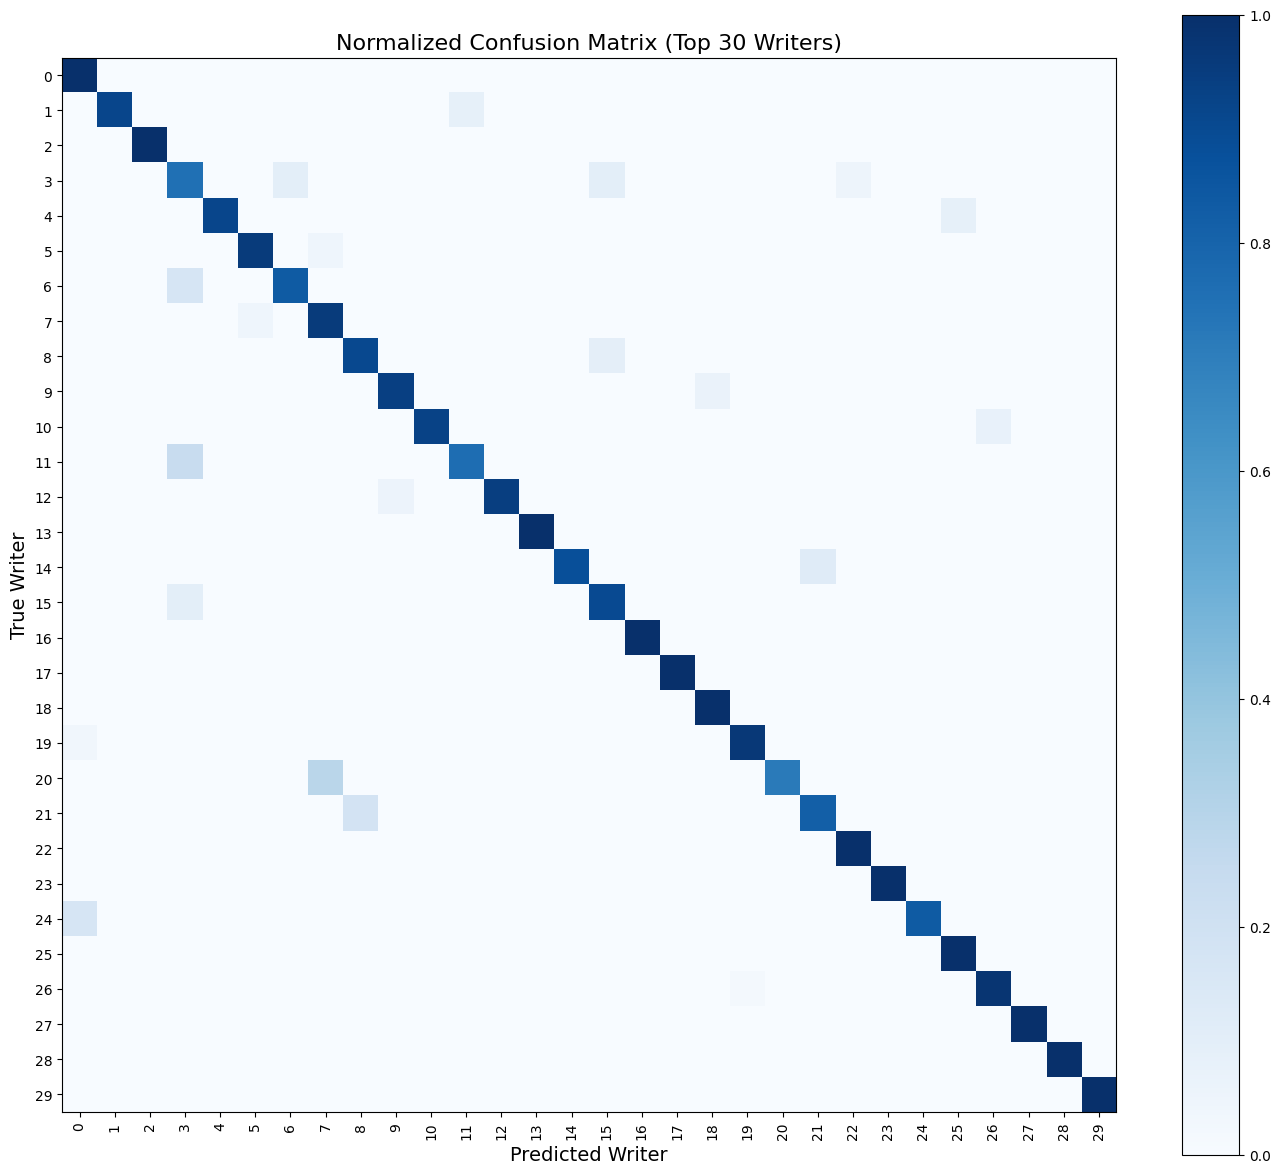

In [44]:
subset_classes = 30


cm_subset = cm[
    :subset_classes,
    :subset_classes
]


# Normalize rows
cm_normalized = (
    cm_subset.astype("float")
    / cm_subset.sum(axis=1)[:, np.newaxis]
)


plt.figure(figsize=(14, 12))


plt.imshow(
    cm_normalized,
    interpolation="nearest",
    cmap="Blues"
)


plt.title(
    "Normalized Confusion Matrix (Top 30 Writers)",
    fontsize=16
)

plt.colorbar()


tick_marks = np.arange(subset_classes)


plt.xticks(
    tick_marks,
    tick_marks,
    rotation=90
)

plt.yticks(
    tick_marks,
    tick_marks
)


plt.xlabel(
    "Predicted Writer",
    fontsize=14
)

plt.ylabel(
    "True Writer",
    fontsize=14
)


plt.tight_layout()

plt.show()

# Training Accuracy Curve

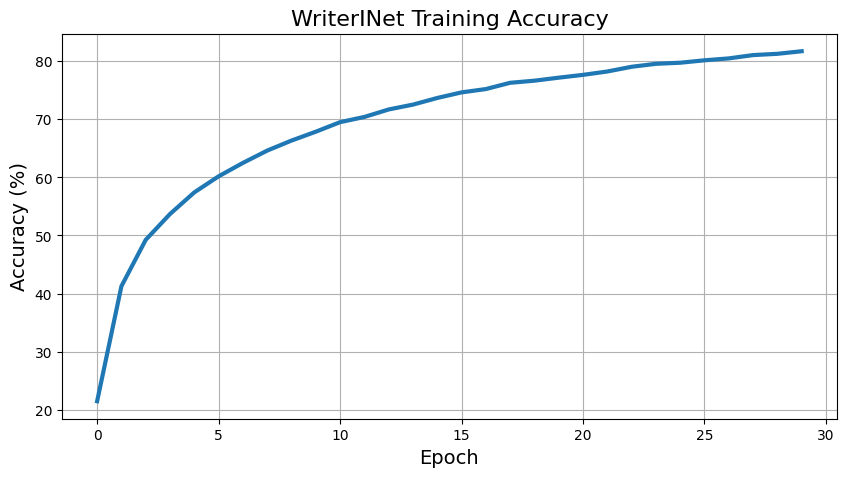

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_accuracies,
    linewidth=3
)

plt.title(
    "WriterINet Training Accuracy",
    fontsize=16
)

plt.xlabel(
    "Epoch",
    fontsize=14
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=14
)

plt.grid()

plt.show()

# Training Loss Curve

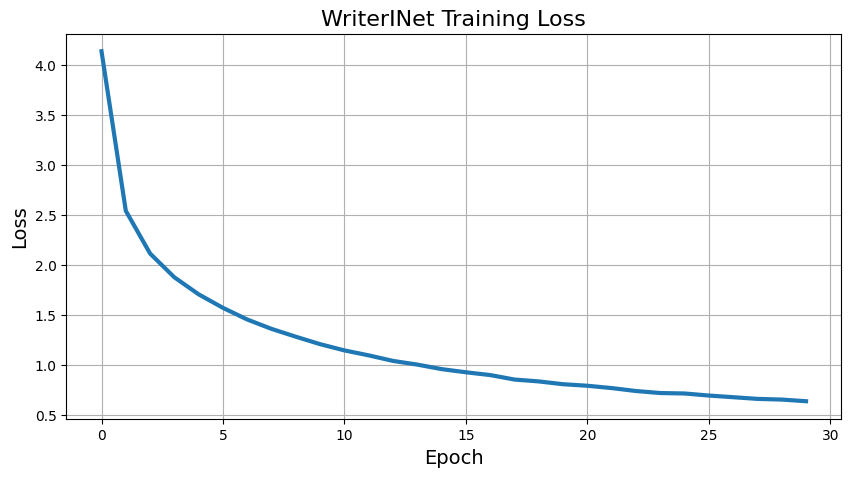

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    linewidth=3
)

plt.title(
    "WriterINet Training Loss",
    fontsize=16
)

plt.xlabel(
    "Epoch",
    fontsize=14
)

plt.ylabel(
    "Loss",
    fontsize=14
)

plt.grid()

plt.show()

# Saving the Trained WriterINet Model

In [47]:
torch.save(
    ann_model.state_dict(),
    "writerinet_ann_model.pth"
)

print("FINAL MODEL SAVED")

FINAL MODEL SAVED


# Saving Extracted WriterINet Features

In [48]:
np.save(
    "X_train.npy",
    X_train
)

np.save(
    "y_train.npy",
    y_train
)

np.save(
    "X_test.npy",
    X_test
)

np.save(
    "y_test.npy",
    y_test
)

print("FEATURES SAVED")

FEATURES SAVED
